# A/B Testing Analysis: Increasing E-Commerce Conversion & Revenue

Analyzes an A/B test to determine whether Variant B improves conversion rate and revenue relative to Variant A, using hypothesis prioritization (ICE/RICE) and statistical significance testing (Mann-Whitney U).


Here are the steps that will be taken during this project:

1. Importing required libraries
2. Data processing and cleaning
3. Prioritize Hypotheses
4. A/B Test Analysis


Below is a description of the hypthoses gathered by the marketing department. 
- Add two new channels for attracting traffic. This will bring 30% more users
- Launch your own delivery service. This will shorten delivery time
- Add product recommendation blocks to the store's site. This will increase conversion and average purchase size
- Change the category structure. This will increase conversion since users will find the products they want more quickly
- Change the background color on the main page. This will increase user engagement
- Add a customer review page. This will increase the number of orders
- Show banners with current offers and sales on the main page. This will boost conversion
- Add a subscription form to all the main pages. This will help you compile a mailing list
- Launch a promotion that gives users discounts on their birthdays


## Preparing Data for Analysis:

#### Importing libraries and uploading the datasets

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
#plotting library
from matplotlib import pyplot as plt

#### Importing datasets

In [4]:
#Since we are working with csv files, using the sep function to handle the data in the spreadsheets
try:
    hypothesis = pd.read_csv('hypotheses_us.csv',sep=';')
    orders = pd.read_csv('orders_us.csv', sep=',', parse_dates=['date'])
    visits = pd.read_csv('visits_us.csv', sep=',', parse_dates=['date'])#removed group as category datatype

except:
    hypothesis = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
    orders = pd.read_csv('/datasets/orders_us.csv', sep=',', parse_dates=['date'])
    visits = pd.read_csv('/datasets/visits_us.csv', sep=',', parse_dates=['date'])#removed group as category datatype
    
pd.options.display.max_colwidth = 150 #adjusts the column width so hypotheses are displayed fully and not cut off.

### Data Cleaning and Processing

#### Hypothesis Dataset Processing

There is no data cleaning or processing that needs to be done on the hypothesis stable. 

In [5]:
hypothesis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


### Orders Dataset Processing

In [6]:
orders.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 105.3 KB


In [7]:
print("Duplicate rows:", orders.duplicated().sum())
print("Unique users:", orders['visitorId'].nunique())

Duplicate rows: 0
Unique users: 1031


In [8]:
## Count how many distinct groups each visitor appears in
groups_per_user = orders.groupby('visitorId')['group'].nunique()
dual_group_users = groups_per_user[groups_per_user > 1].index
first_visit_group = (
    orders.sort_values(['visitorId', 'date'])
    .groupby('visitorId').first()['group']
    .reset_index()
)
first_visit_group.columns = ['visitorId', 'first_group']

In [9]:
# Count how many distinct groups each visitor appears in
groups_per_user = orders.groupby('visitorId')['group'].nunique()
dual_group_users = groups_per_user[groups_per_user > 1].index

print(f"Users found in both groups: {len(dual_group_users)}")

Users found in both groups: 58


In [10]:
# Remove those multiple group users to preserve the integrity for the A/B testing
order_data = orders[~orders['visitorId'].isin(dual_group_users)]
print("Orders remaining after removing dual-group users:", len(order_data))
print(order_data['group'].value_counts())

Orders remaining after removing dual-group users: 1016
B    548
A    468
Name: group, dtype: int64


### Visits Dataset Processing

In [11]:
visits.info()
print("Duplicate rows:", visits.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
Duplicate rows: 0


In [12]:
# Quick view of dataset
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


## Part 1. Prioritizing Hypothesis

The file hypotheses_us.csv contains nine hypothesis on boosting an online store's revenue with Reach, Impact, Confidence, and Effort (aka RICE) specified for each.

RICE has four components:
- Reach — how many users will be affected by the update you want to introduce
- Impact — how strongly this update will affect the users, their experience, and their satisfaction with the product
- Confidence — how sure you are that your product will affect them in this way
- Effort — how much will it cost to test the hypothesis


<b>The task is to:</b>
- Apply the ICE framework to prioritize hypothesis. Sort them in descending order of priority.
- Apply the RICE framework to prioritize hypothesis. Sort them in descending order of priority.
- Show how the prioritization of hypothesis changes when you use RICE instead of ICE. Provide an explanation for the changes.

In [13]:
# Viewing the dataframe
hypothesis

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6
1,Launch your own delivery service. This will shorten delivery time,2,5,4,10
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8
4,Change the background color on the main page. This will increase user engagement,3,1,1,1
5,Add a customer review page. This will increase the number of orders,3,2,2,3
6,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3
7,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5
8,Launch a promotion that gives users discounts on their birthdays,1,9,9,5


### 1. Apply the ICE framework to prioritize hypothesis in descending order of priority. 

In [14]:
#ICE
hypothesis['ICE']= (hypothesis['Impact'] * hypothesis['Confidence']) /hypothesis['Effort']

hypothesis[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)


,Hypothesis,ICE
8,Launch a promotion that gives users discounts on their birthdays,16.200000
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000
1,Launch your own delivery service. This will shorten delivery time,2.000000
5,Add a customer review page. This will increase the number of orders,1.333333
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000
4,Change the background color on the main page. This will increase user engagement,1.000000


<b>Insight: </b> 8, 0, 7 6 and 2 where the top hypotheses with 8 being number one with 16.2.  

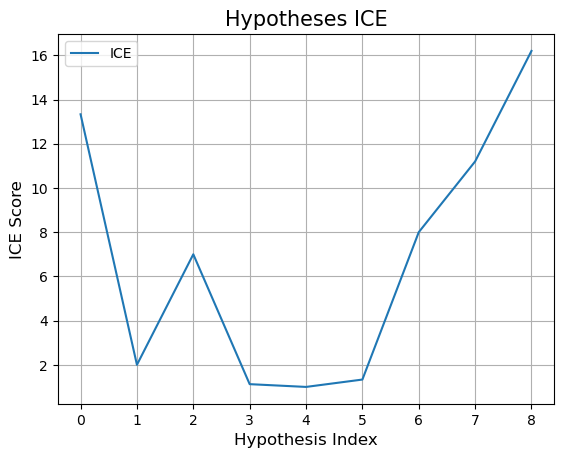

In [15]:
# Plotting ICE

hypothesis.plot(y='ICE', use_index=True)
plt.title('Hypotheses ICE',fontdict={'size':15})
plt.xlabel('Hypothesis Index',fontdict={'size':12})
plt.ylabel('ICE Score',fontdict={'size':12})
plt.grid(True)
plt.legend() 
plt.show()

### 2. Apply the RICE framework to prioritize hypothesis in descending order.

In [16]:
#RICE
hypothesis['RICE']= (hypothesis['Impact'] * hypothesis['Reach'] * hypothesis['Confidence']) /hypothesis['Effort']

hypothesis[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

,Hypothesis,RICE
7,Add a subscription form to all the main pages. This will help you compile a mailing list,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,56.0
0,Add two new channels for attracting traffic. This will bring 30% more users,40.0
6,Show banners with current offers and sales on the main page. This will boost conversion,40.0
8,Launch a promotion that gives users discounts on their birthdays,16.2
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,9.0
1,Launch your own delivery service. This will shorten delivery time,4.0
5,Add a customer review page. This will increase the number of orders,4.0
4,Change the background color on the main page. This will increase user engagement,3.0


<b>Insight:</b> 7, 2 , 0, 6, 8 were the top hypotheses with 0 and 6 having the same RICE score.  8 fell from 1st with ICE to the bottom of the top 5.  6 didn't change position, 7 and 0 are the only two that remained in the top 3. 

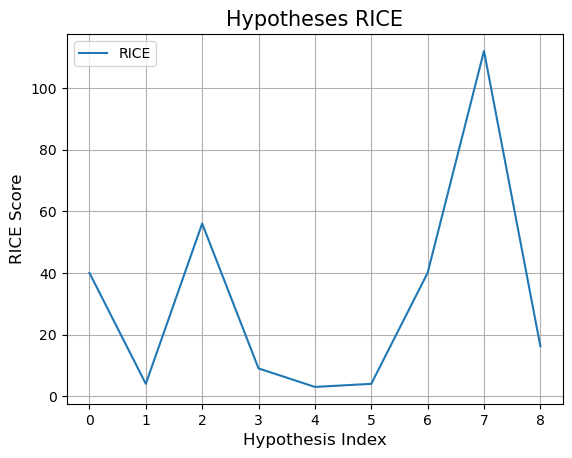

In [17]:
#Plotting RICE

hypothesis.plot(y='RICE', use_index=True)
plt.title('Hypotheses RICE',fontdict={'size':15})
plt.xlabel('Hypothesis Index',fontdict={'size':12})
plt.ylabel('RICE Score',fontdict={'size':12})
plt.grid(True)
plt.legend() 
plt.show()

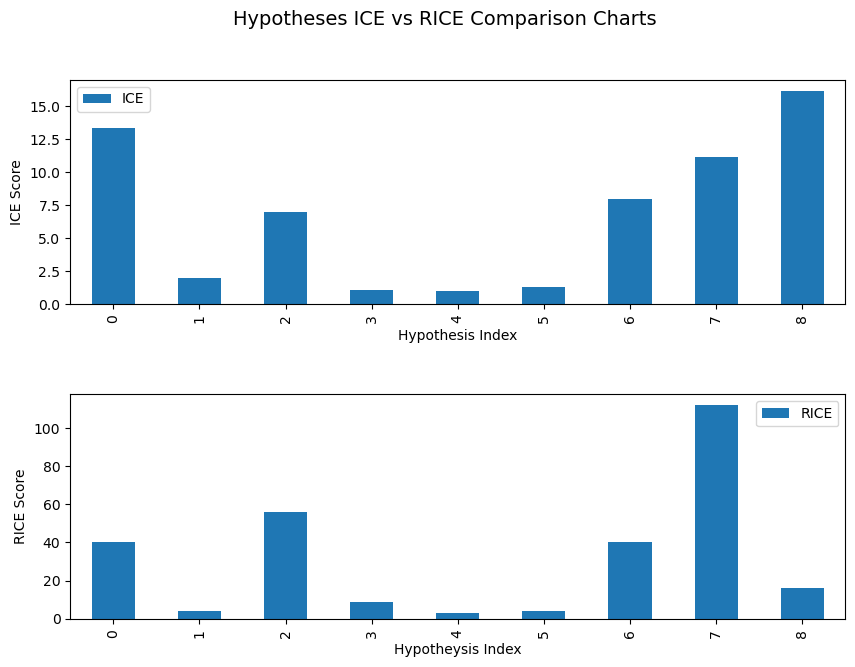

In [18]:
# Compare ICE and RICE
figure, axes = plt.subplots(2, 1, figsize=(10, 7))
# make a little extra space between the subplots
figure.subplots_adjust(hspace=0.4)


# Create each subplot on the specified axes
IceHyp = hypothesis.plot(use_index=True, y="ICE", kind="bar", ax=axes[0])   
axes[0].set(xlabel="Hypothesis Index", ylabel="ICE Score", label="Hypothesis ICE Score")
   
RiceHyp = hypothesis.plot(use_index=True, y="RICE", kind="bar", ax=axes[1])
axes[1].set(xlabel="Hypotheysis Index", ylabel="RICE Score", label="Hypothesis RICE Score")

figure.suptitle('Hypotheses ICE vs RICE Comparison Charts', fontsize=14)
plt.show()

## Testing the Hypothesis that Proportions Are Equal

In [19]:
hypothesis[['Hypothesis','ICE', 'RICE']].sort_values(by='ICE', ascending=False)

,Hypothesis,ICE,RICE
8,Launch a promotion that gives users discounts on their birthdays,16.200000,16.2
0,Add two new channels for attracting traffic. This will bring 30% more users,13.333333,40.0
7,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000,112.0
6,Show banners with current offers and sales on the main page. This will boost conversion,8.000000,40.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000,56.0
1,Launch your own delivery service. This will shorten delivery time,2.000000,4.0
5,Add a customer review page. This will increase the number of orders,1.333333,4.0
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000,9.0
4,Change the background color on the main page. This will increase user engagement,1.000000,3.0


<b><h3> Conclusion for Prioritizing Hypotheses:</h3> </b> From both of the ICE and RICE plots, we get a better visual of how the two represent the hypotheses presented.  We can see that numbers 3, 4 and 5 can be dropped; they performed poorly on both spectrums. Changing the category structure(#3), background color(#4) and adding a customer review page(#5) would have no significant effects customer base or revenue.  These are 'cosmetic' changes.  
<p>
The 5 Hypotheses that should be focused on are numbers 7, 0, 2, 6 and 8.  From those 5, the top three would be 7, 8 and 0. 
Hypothesis 7 maintained good standing in both ICE and RICE categories. Subscription forms are an excellent way to retain current visitors and give new visitors more insights into what the company is doing and has to offer. 
<p>
Promotional discounts(#8) and adding channels to bring in more traffic(#0) both garner focus in increasing customer base and revenue. Even though (#8) performed poorly in terms of RICE; it did so well in the ICE category that it brought it in line with the second best hypothesis(#0). Reaching more visitors and giving discounts have been proven industry actioons in increasing customer base and revenue potential.

# Part 2. A/B Test Analysis


<b>Analyze the A/B test:</b>

1. Graph cumulative revenue by group. Make conclusions and conjectures.
2. Graph cumulative average order size by group. Make conclusions and conjectures.
3. Graph the relative difference in cumulative average order size for group B compared with group A. Make conclusions and conjectures.
4. Calculate each group's conversion rate as the ratio of orders to the number of visits for each day. Plot the daily conversion rates of the two groups and describe the difference. Draw conclusions and make conjectures.
5. Plot a scatter chart of the number of orders per user. Make conclusions and conjectures.
7. Calculate the 95th and 99th percentiles for the number of orders per user. Define the point at which a data point becomes an anomaly.
8. Plot a scatter chart of order prices. Make conclusions and conjectures.
9. Calculate the 95th and 99th percentiles of order prices. Define the point at which a data point becomes an anomaly.
10. Find the statistical significance of the difference in conversion between the groups using the raw data. Make conclusions and conjectures.
11. Find the statistical significance of the difference in average order size between the groups using the raw data. Make conclusions and conjectures.
12. Find the statistical significance of the difference in conversion between the groups using the filtered data. Make conclusions and conjectures.
13. Find the statistical significance of the difference in average order size between the groups using the filtered data. Make conclusions and conjectures.



#### 1. Graph cumulative revenue by group.

In [20]:
# Building an array with unique paired date-group values 

datesGroups = order_data[['date','group']].drop_duplicates()
datesGroups

,date,group
0,2019-08-15,B
7,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B
55,2019-08-01,A
...,...,...
1068,2019-08-12,A
1114,2019-08-13,B
1116,2019-08-13,A
1149,2019-08-14,B


In [21]:
# Cumulative Visitors
visitorsAggregated = datesGroups.apply(
    lambda x: visits[
        np.logical_and(
            visits['date'] <= x['date'], visits['group'] == x['group']
        )
    ].agg(
        {'date' : 'max',
         'group' : 'max',
         'visits' : 'sum'
        }
    ),
    axis=1).sort_values(by=['date','group'])
visitorsAggregated

,date,group,visits
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845
...,...,...,...
533,2019-08-29,B,17708
757,2019-08-30,A,18037
690,2019-08-30,B,18198
958,2019-08-31,A,18736


In [22]:
# Cumulative transactions/buyers and revenue
ordersAggregated = datesGroups.apply(
    lambda x: order_data[
        np.logical_and(
            order_data['date'] <= x['date'], order_data['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transactionId': pd.Series.nunique,
            'visitorId': pd.Series.nunique,
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])
ordersAggregated

,date,group,transactionId,visitorId,revenue
55,2019-08-01,A,23,19,2266.6
66,2019-08-01,B,17,17,967.2
175,2019-08-02,A,42,36,3734.9
173,2019-08-02,B,40,39,3535.3
291,2019-08-03,A,66,60,5550.1
...,...,...,...,...,...
533,2019-08-29,B,510,490,74576.7
757,2019-08-30,A,460,437,52363.7
690,2019-08-30,B,531,511,77863.5
958,2019-08-31,A,468,445,53212.0


In [23]:
# Merging the two tables into one and giving its columns descriptive names
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders','buyers', 'revenue', 'visitors']

cumulativeData

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713
2,2019-08-02,A,42,36,3734.9,1338
3,2019-08-02,B,40,39,3535.3,1294
4,2019-08-03,A,66,60,5550.1,1845
...,...,...,...,...,...,...
57,2019-08-29,B,510,490,74576.7,17708
58,2019-08-30,A,460,437,52363.7,18037
59,2019-08-30,B,531,511,77863.5,18198
60,2019-08-31,A,468,445,53212.0,18736


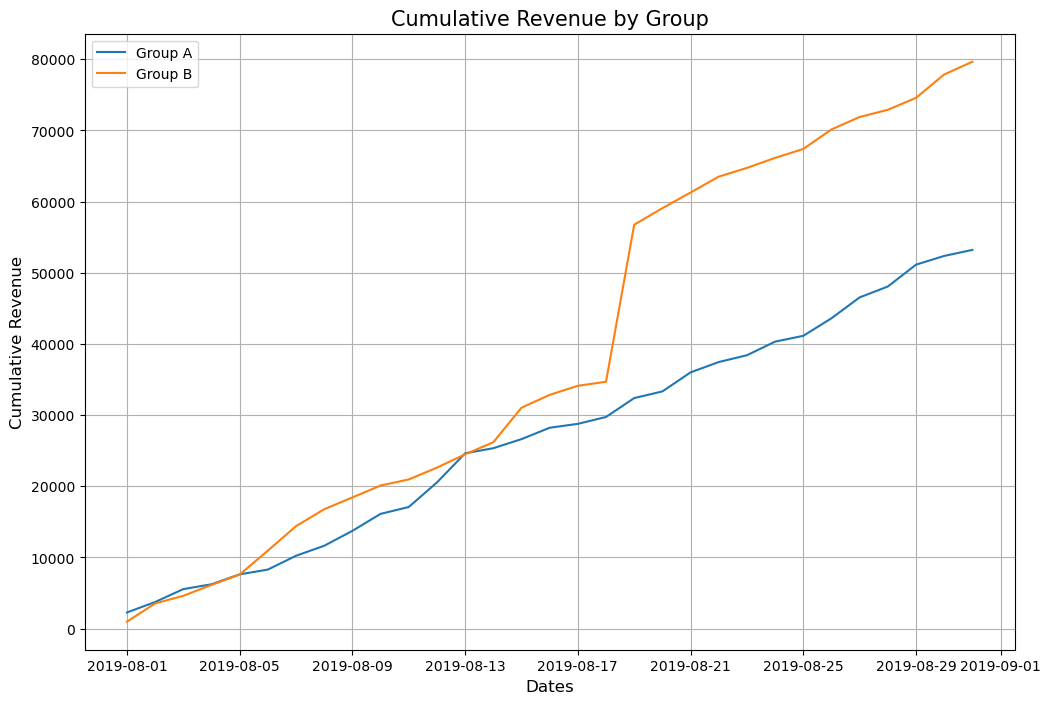

In [24]:
# DataFrame with cumulative orders and cumulative revenue by day, group A
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# DataFrame with cumulative orders and cumulative revenue by day, group B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

plt.figure(figsize=(12,8)) 
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='Group A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='Group B')
plt.title('Cumulative Revenue by Group',fontdict={'size':15})
plt.xlabel('Dates',fontdict={'size':12})
plt.ylabel('Cumulative Revenue',fontdict={'size':12})
plt.grid(True)
plt.legend() 
plt.show()

<b>Insight:</b>  Revenue tracks closely until 2019-08-17, when Group B pulls ahead.

### 2. Cumulative average order size by group.

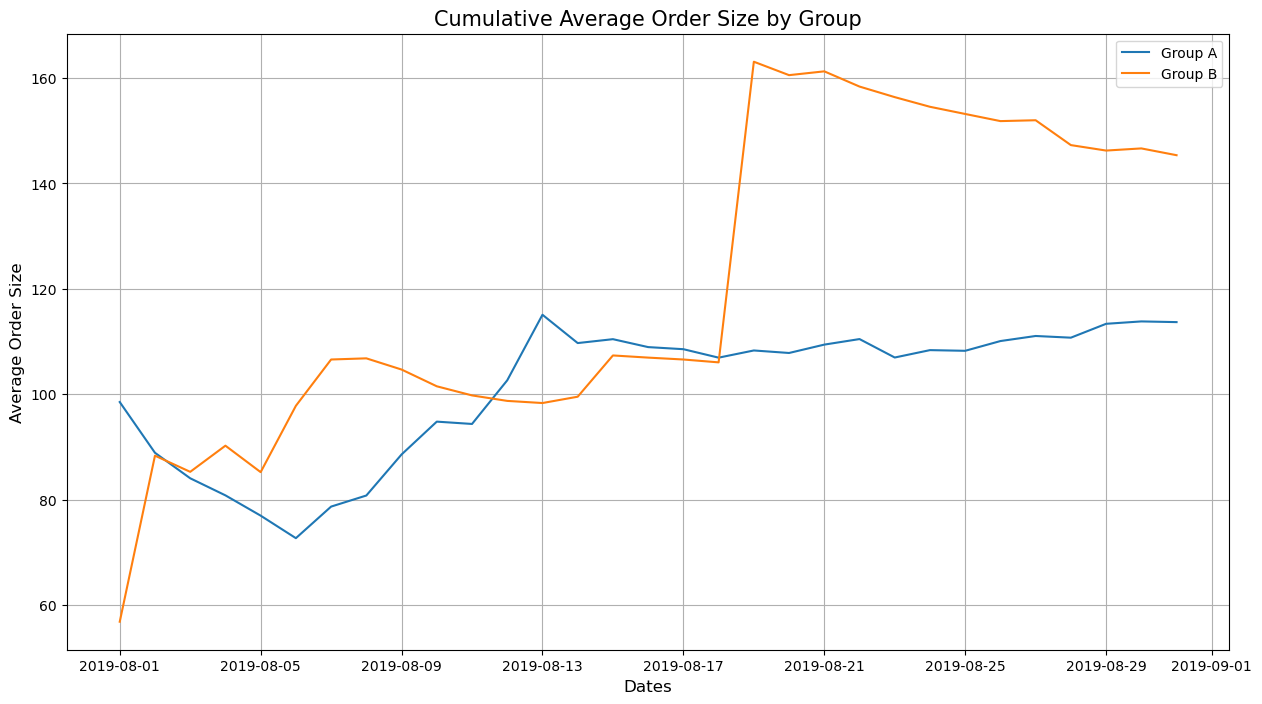

In [25]:
# Plotting average order size
plt.figure(figsize=(15,8)) 
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='Group A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='Group B')

plt.title('Cumulative Average Order Size by Group',fontdict={'size':15})
plt.xlabel('Dates',fontdict={'size':12})
plt.ylabel('Average Order Size',fontdict={'size':12})
plt.grid(True)
plt.legend() 
plt.show()

<b>Insight:</b> Group B spikes at the same point (2019-08-17) when pertaining to revenue, then trends down. Group A, once it had reached it's peak at 2019-08-13, levels off and stay constent. 

### 3. Relative difference in cumulative average order size for group B vs. group A.

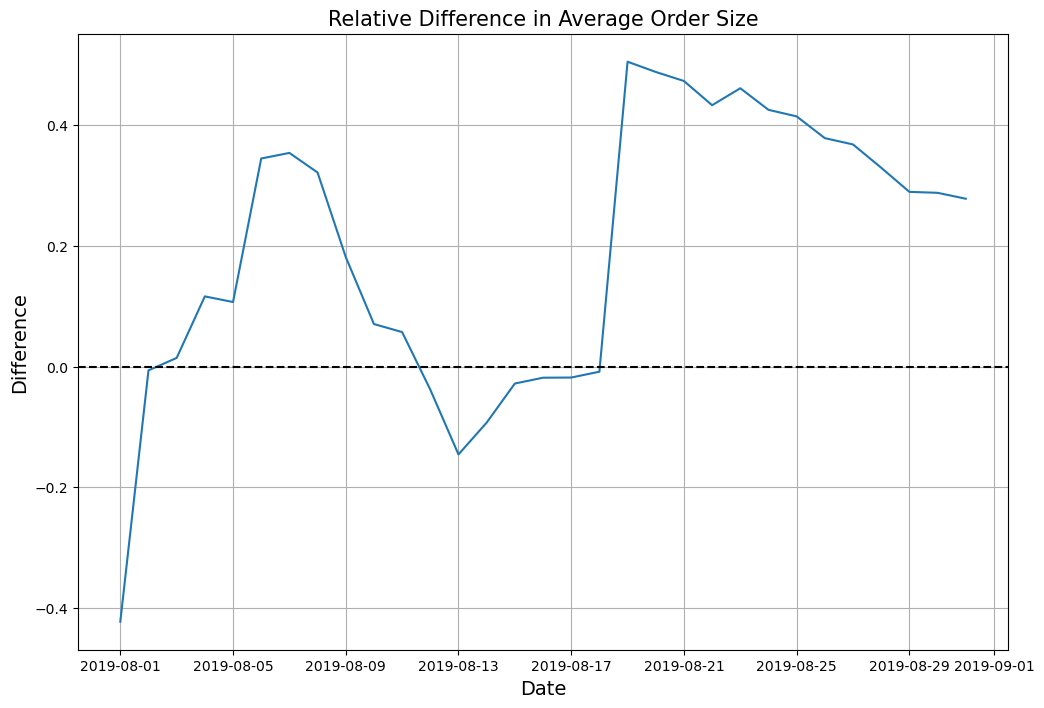

In [26]:
# Realtive difference in average order size, B vs A
mergedCumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# Plotting relative difference for average purchase sizes
plt.figure(figsize=(12,8)) 
plt.plot(mergedCumulativeRevenue['date'],
         (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/
         (mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)
plt.title("Relative Difference in Average Order Size", fontdict={'size':15})
plt.xlabel("Date", fontdict={'size':14})
plt.ylabel("Difference", fontdict={'size':14})
plt.grid(True)

#adding the x-axis
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

<b>Insight:</b> Two sharp spikes suggest a small number of abnormally large orders. This will be looked into further in the analysis process. 

### 4. Daily conversion rate by group

In [27]:
# Quick table view
cumulativeData.head(2) #df overview

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713


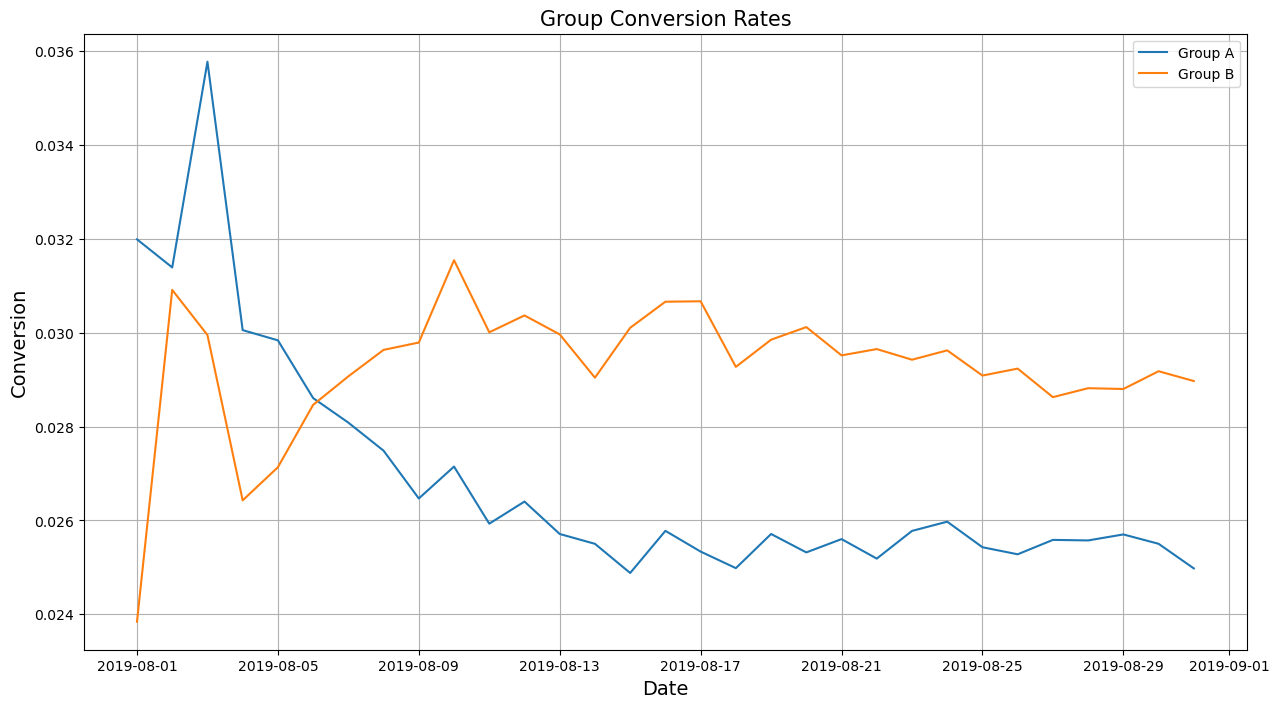

In [28]:
# Calculating conversion rate
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# Selecting group A 
cumulativeData_A = cumulativeData[cumulativeData['group']=='A']

# Selecting group B
cumulativeData_B = cumulativeData[cumulativeData['group']=='B']

# Plotting the graphs
plt.figure(figsize=(15,8)) 
plt.plot(cumulativeData_A['date'], cumulativeData_A['conversion'], label='Group A')
plt.plot(cumulativeData_B['date'], cumulativeData_B['conversion'], label='Group B')
plt.title("Group Conversion Rates", fontdict={'size':15}) #fontdict adds text formatting
plt.xlabel("Date", fontdict={'size':14})
plt.ylabel("Conversion", fontdict={'size':14})
plt.grid(True)
plt.legend()
plt.show()

<b>Insight:</b> Both groups fluctuate early on, then level off. Group B shows
noticeable spikes between the 9th and 17th relative to Group A.

### 5. Orders per user

To determine orders by users, we want a full and complete overview of the data.  Groups and revenue are irrelevant so those columns are removed. 

Note: This section uses the unfiltered orders dataset intentionally, to establish a baseline understanding of order volume and outliers across all customers before any data-integrity filtering. Group-comparison statistics later in this notebook use the cleaned order_data (dual-group users removed) to ensure valid A/B comparisons.

In [29]:
orders_by_users = (
    orders.drop(['group', 'revenue', 'date'], axis=1) # Removing columns not used or relevant
    .groupby('visitorId', as_index=False) # Group the orders by users
    .agg({'transactionId': pd.Series.nunique}) # Calculate aggregated metrics on unique transaction ID 
)

orders_by_users.columns = ['userId', 'orders']
orders_by_users.sort_values(by='orders', ascending=False).head(10)

,userId,orders
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


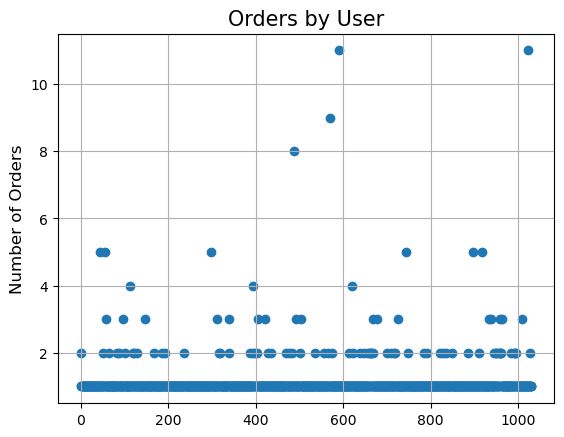

In [30]:
# Scatter plot
x_values = pd.Series(range(0,len(orders_by_users)))

plt.scatter(x_values, orders_by_users['orders'])
plt.title("Orders by User", fontdict={'size':15})

plt.ylabel("Number of Orders", fontdict={'size':12})

plt.grid()

<b>Insight:</b> As determined early in the analysis process, there are order spikes as shown in the table and scatterplot. 4 orders have higher than normal order sizes with 2 orders almost maxing out. Two users have 11 orders which are shown clearly on the plot. 

### 6. Order count percentiles (anomaly threshold)

In [31]:
print(np.percentile(orders_by_users['orders'], [90, 95, 99]))

[1. 2. 4.]


No more than 5% of users placed more than 2 orders, and 10% of users made more than 1.

It would be reasonable to set 2 to 3 orders per user as the cutoff for "typical" user behavior.

### 7. Order prices. 

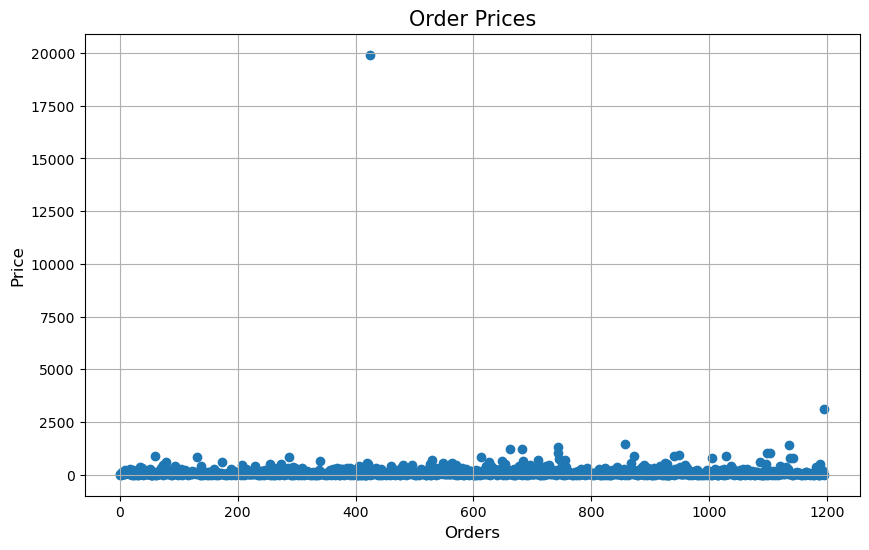

In [32]:
orders.sort_values(by='revenue',ascending=False).head(10)

x_values = pd.Series(range(0,len(orders['revenue'])))

plt.figure(figsize=(10, 6)) 
plt.scatter(x_values, orders['revenue']) 
plt.title("Order Prices", fontdict={'size':15})
plt.xlabel("Orders", fontdict={'size':12})
plt.ylabel("Price", fontdict={'size':12})
plt.grid()

<b>Insight:</b> Now we can see what the previous spikes have created. A small number of very large orders can be seen as well.

### 8. Calculate the 95th and 99th percentiles of order prices.

In [33]:
print(np.percentile(order_data['revenue'], [90, 95, 99]).round())

[281. 414. 830.]


<b>Insight:</b>

5% placed orders that cost more than 436 USD.

1% placed orders that cost more than 830 USD.

Orders outside of the 1% range can be considered anomalies. 

## Significance Testing (Raw Data)

We'll create the variables orders_userA and orders_usersB to store the columns ['userId', 'orders']. For users with at least one order, we'll indicate the number of orders made.

In [34]:
# Quick view of order data
order_data.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B


In [35]:
# Quick view of visit data
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [36]:
import scipy.stats as stats # library to work with mann whitney
from pandas.core.reshape.concat import concat # For finding the samples


orders_userA = order_data[order_data['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
orders_userA.columns = ['userId', 'orders']#visitorID to userID and transacId to orders

orders_usersB = order_data[order_data['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
orders_usersB.columns = ['userId', 'orders'] 

sampleA = pd.concat([orders_userA['orders'],
                     pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits']
                                                                           .sum() - len(orders_userA['orders'])), name='orders')],axis=0)

sampleB = pd.concat([orders_usersB['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits']
                                                                           .sum() - len(orders_usersB['orders'])), name='orders')],axis=0)
# P VALUE
print("The P-Value is:","{0:.4f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))
# RELATIVE GAIN for group 1
print("Group B's relative gain is:","{0:.4f}".format(sampleB.mean()/sampleA.mean()-1)) 



The P-Value is: 0.0110
Group B's relative gain is: 0.1598


In [45]:
# Null and alternative hypotheses testing

alpha = .05 #significance level

result_grp = stats.mannwhitneyu(sampleA, sampleB)

print('P-value: ','{0:.4f}'.format(result_grp.pvalue))

if (result_grp.pvalue < alpha):
    print("Null hypothesis rejected: there is significant difference in the groups using the raw data.")
else:
    print("Failed to reject the null hypothesis: there is no significant difference in the groups using the raw data.") 


P-value:  0.0110
Null hypothesis rejected: there is significant difference in the groups using the raw data.


<b>Insight:</b> The P-value (0.0110) is smaller than the 0.05 significance level, so we reject the null hypothesis. Group B shows a 15.98% higher conversion rate than Group A using raw data; a statistically significant difference.

### 10. Statistical significance in average order size between the groups using the raw data. 

In [38]:
# P VALUE
print("The P-Value is:",'{0:.4f}'.format(stats.mannwhitneyu(order_data[order_data['group']=='A']['revenue'],
                                          order_data[order_data['group']=='B']['revenue'])[1]))

# RELATIVE GAIN for group B
print("Group B's relative gain is:",'{0:.4f}'.format(order_data[order_data['group']=='B']['revenue'].
                       mean()/order_data[order_data['group']=='A']['revenue'].mean()-1))

The P-Value is: 0.8622
Group B's relative gain is: 0.2783


In [39]:
## Null and alternative hypotheses testing

alpha = .05 #significance level

# Renames the PValue from above so easier to do comparison.
results_OS = stats.mannwhitneyu(order_data[order_data['group']=='A']['revenue'],
                                          order_data[order_data['group']=='B']['revenue'])[1]

print('pvalue:','{0:.4f}'.format(results_OS))#Prints the PValue from above.
print()

if (results_OS > alpha):
    print('There is no significant difference in average order size between the groups using the raw data.')
else:
    print('There is significant difference in average order size between the groups using the raw data.')

pvalue: 0.8622

There is no significant difference in average order size between the groups using the raw data.


<b>*Insight:</b>The P-value (0.8622) is far above the 0.05 significance threshold, so this test fails to reject the null hypothesis — there is no statistically significant difference in average order size between the groups using raw data. Group B's raw average order value is 27.83% higher than Group A's, but this difference is not statistically reliable and may be driven by a small number of large orders.

### 11.Statistical significance in the difference between the groups using the filtered data. 

In [40]:
# First to see how many users can be identified as outliers or anamolies in terms of customer revenue.

usersWithManyOrders = pd.concat([orders_userA[orders_userA['orders'] > 2]['userId'], # More than 2 orders for A
                                 orders_usersB[orders_usersB['orders'] > 2]['userId']], # More than 2 orders for BB
                                axis = 0)

# How many users with any order over $2,000 
usersWithExpensiveOrders = order_data[order_data['revenue'] > 2000]['visitorId'] 

abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders],
                          axis = 0).drop_duplicates().sort_values()

print(f"{len(abnormalUsers)} users identified as anomalies.")

9 users identified as anomalies.


Now prepare samples of the number of orders per user for each test group.

In [41]:
sampleAFiltered = pd.concat([orders_userA[np.logical_not(orders_userA['userId'] \
                  .isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'] \
                  .sum() - len(orders_userA['orders'])),name='orders')],axis=0)

sampleBFiltered = pd.concat([orders_usersB[np.logical_not(orders_usersB['userId'] \
                 .isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'] \
                 .sum() - len(orders_usersB['orders'])),name='orders')],axis=0) 

Applying the statistical Mann-Whitney criterion to the resulting samples.

In [42]:
# Null and alternative hypotheses testing
alpha = .05 #significance level

result_grp2 = stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)

print('P-value: ','{0:.4f}'.format(result_grp2.pvalue))

relative_gain_filtered = sampleBFiltered.mean() / sampleAFiltered.mean() - 1
print("Relative gain (filtered):", "{0:.4f}".format(relative_gain_filtered))

if (result_grp2.pvalue < alpha):
    print("Null hypothesis rejected: the difference is statistically significant")
else:
    print("Failed to reject the null hypothesis: we can't make conclusions about the difference")


P-value:  0.0096
Relative gain (filtered): 0.1806
Null hypothesis rejected: the difference is statistically significant


With the null hypothesis rejected (p = 0.0096), Group B's conversion advantage remains statistically significant after removing the 9 anomalous users. The relative gain actually increases slightly, from 15.98% (raw) to 18.06% (filtered) — confirming the conversion improvement is a genuine effect, not one inflated by outliers.

### 12.Statistical significance of the difference in average order size using the filtered data.

In [43]:
print('{0:.4f}'.format(stats.mannwhitneyu(
    order_data[np.logical_and(
        order_data['group']=='A',
        np.logical_not(order_data['visitorId'].isin(abnormalUsers)))]['revenue'],
    order_data[np.logical_and(
        order_data['group']=='B',
        np.logical_not(order_data['visitorId'].isin(abnormalUsers)))]['revenue'])[1]))

print("Group B's relative gain is:",'{0:.4f}'.format(
    order_data[np.logical_and(order_data['group']=='B',np.logical_not(order_data['visitorId'].isin(abnormalUsers)))]['revenue'].mean()/
    order_data[np.logical_and(
        order_data['group']=='A',
        np.logical_not(order_data['visitorId'].isin(abnormalUsers)))]['revenue'].mean() - 1))

0.6730
Group B's relative gain is: -0.0913


In [44]:
# Null and alternative hypotheses testing

alpha = .05 #significance level

# Renames the PValue from above so easier to do comparison.
fos = stats.mannwhitneyu(order_data[np.logical_and(
        order_data['group']=='A',
        np.logical_not(order_data['visitorId'].isin(abnormalUsers)))]['revenue'],
    order_data[np.logical_and(
        order_data['group']=='B',
        np.logical_not(order_data['visitorId'].isin(abnormalUsers)))]['revenue'])[1]

print('P-value:','{0:.4f}'.format(fos))#Prints the PValue from above.
print()

if (fos > alpha):
    print('Difference in average order size is still not significant.')
else:
    print('Null hypothesis rejected: the average order size difference is statisticaly significant.')

P-value: 0.6730

Difference in average order size is still not significant.


<b> Insight:</b> After removing anomalies, conversion gain moved from 15.98% (raw) to 18.06% (filtered) — a small increase, reinforcing that Group B's conversion improvement is real and not outlier-driven. Average order size tells the opposite story: Group B's raw advantage of 27.83% drops to -9.13% once anomalies are removed, showing that a handful of unusually large orders, not a genuine difference in typical order size, were responsible for Group B's raw revenue edge.

<b><h3> Conclusion for A/B Analysis:</b></h3> 
Conversion rate: statistically significant improvement for Group B, both before (15.98%) and after (18.06%) removing anomalous users.

Average order size: no statistically significant difference in either raw or filtered data. Group B's raw revenue advantage (27.83%) was driven by a handful of large orders — once removed, Group B's order size is actually 9.13% lower than Group A's, with no statistical significance either way.

<b>Recommendation:</b> Deploy Variant B. The conversion rate gain is real and consistent across both raw and filtered data; the lack of order-size improvement doesn't change that conclusion, since conversion — not order size — was the primary metric.